In [11]:
import sys
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from src.models import vectorize_data, train_model, evaluate_model, plot_roc_curve
import seaborn as sns
import matplotlib.pyplot as plt


In [10]:
# Change the working directory to your project folder
os.chdir("C:/Users/User/Documents/3 semester/text mining/project/sentiment_analysis_project")

# Verify the new working directory
print("New Working Directory:", os.getcwd())

New Working Directory: C:\Users\User\Documents\3 semester\text mining\project\sentiment_analysis_project


In [12]:
# Load the data
df = pd.read_csv("data/cleaned_reviews.csv", low_memory=False)

# Filter only the necessary columns
df_filtered = df[['is_recommended', 'cleaned_review_text']].copy()  # Use .copy() to avoid SettingWithCopyWarning

# Ensure 'is_recommended' is numeric and handle missing values
df_filtered['is_recommended'] = pd.to_numeric(df_filtered['is_recommended'], errors='coerce')
df_filtered = df_filtered.dropna(subset=['is_recommended', 'cleaned_review_text'])

# Convert 'is_recommended' to integer
df_filtered['is_recommended'] = df_filtered['is_recommended'].astype(int)

# Splitting data into X (features) and y (target)
X = df_filtered['cleaned_review_text']
y = df_filtered['is_recommended']

# Splitting into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Vectorize the text data
X_train_tfidf, X_test_tfidf, vectorizer = vectorize_data(X_train, X_test)

# Display a sample of the processed DataFrame for verification
print("Sample processed data:")
from IPython.display import display
display(df_filtered.head(10))  # Use display for better readability in Jupyter Notebook

# Apply SMOTE to balance the classes
smote = SMOTE(random_state=42)
X_train_tfidf_balanced, y_train_balanced = smote.fit_resample(X_train_tfidf, y_train)

# Display the balanced class distribution
print("Class distribution after applying SMOTE:")
print(pd.Series(y_train_balanced).value_counts())

Sample processed data:


,is_recommended,cleaned_review_text
0,1,use nudestix citrus clean balm makeup melt dou...
1,0,buy lip mask read review hype unfortunately me...
2,1,review title say excited bed apply lip mask di...
3,1,ve love formula long time honestly not use nig...
4,1,dry crack lip week use learn bedside think lit...
5,1,scent not favourite work great night sleep mor...
6,0,ill star nice packaging lovely scent initial a...
7,1,use night m put makeup love way not reapply ni...
8,1,love stuff sample size sephora birthday gift r...
9,1,purchase sweet candy scent local sephora obses...


Class distribution after applying SMOTE:
is_recommended
1    324184
0    324184
Name: count, dtype: int64


**Logistic Regression**


Logistic Regression Results:
Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.81      0.73     15682
           1       0.96      0.92      0.94     81046

    accuracy                           0.90     96728
   macro avg       0.81      0.87      0.83     96728
weighted avg       0.91      0.90      0.90     96728

Confusion Matrix:
[[12775  2907]
 [ 6772 74274]]


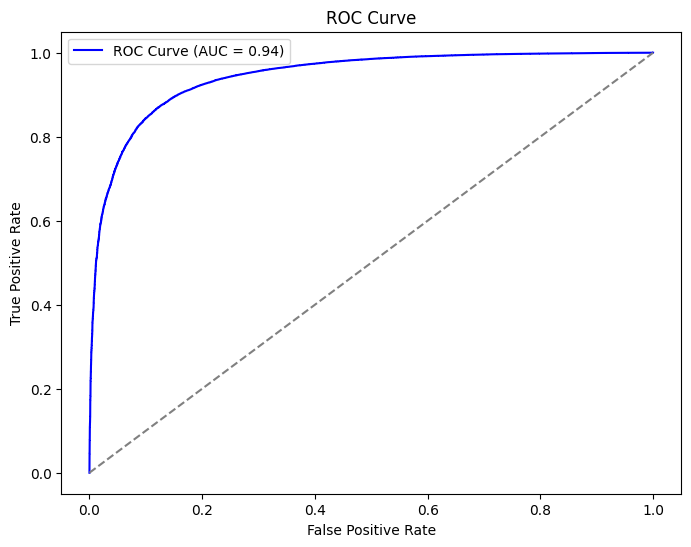

In [13]:
# Train 
logistic_model = train_model(X_train_tfidf_balanced, y_train_balanced, model_type='logistic')

# Evaluate 
print("\nLogistic Regression Results:")
evaluate_model(logistic_model, X_test_tfidf, y_test)

# Plot ROC Curve 
plot_roc_curve(logistic_model, X_test_tfidf, y_test)

- **Accuracy:** **90%** indicates the model correctly classifies the majority of reviews.
- **ROC Curve & AUC:**  
  - **AUC = 0.94**, confirming the model’s excellent ability to distinguish between **positive and negative** reviews.  

**Insights:**  
✔ The model is highly effective for **positive review classification** but has **moderate precision for negative reviews**, meaning some negative reviews may be misclassified as positive.  
✔ The **high recall for negative reviews** ensures that most negative feedback is captured. 

**Naive Bayes**


Naive Bayes Results:
Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.86      0.66     15682
           1       0.97      0.86      0.91     81046

    accuracy                           0.86     96728
   macro avg       0.76      0.86      0.79     96728
weighted avg       0.90      0.86      0.87     96728

Confusion Matrix:
[[13448  2234]
 [11382 69664]]


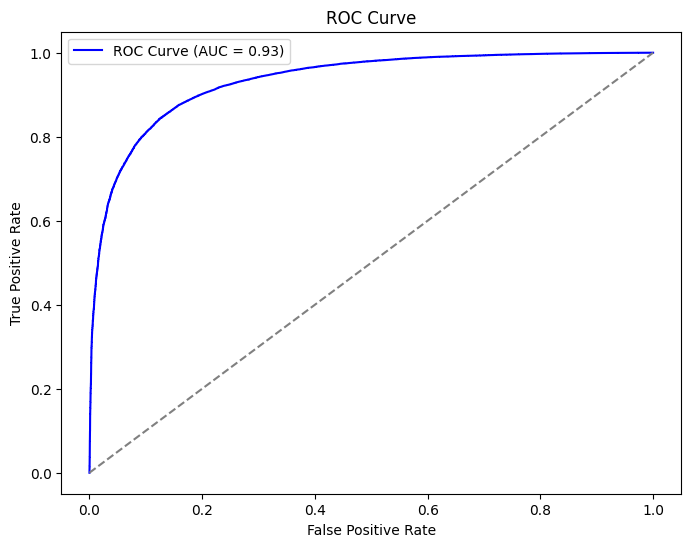

In [22]:
# Train 
naive_bayes = train_model(X_train_tfidf_balanced, y_train_balanced, model_type='naive_bayes')

# Evaluate 
print("\nNaive Bayes Results:")
evaluate_model(naive_bayes, X_test_tfidf, y_test)

# Plot ROC Curve 
plot_roc_curve(naive_bayes, X_test_tfidf, y_test)

- **Accuracy:** **86%**, indicating good overall classification ability.
- **ROC Curve & AUC:**  
  - **AUC = 0.93**, suggesting strong model capability in distinguishing between **positive and negative** reviews.  

**Insights:**  
✔ The **high recall for both positive and negative reviews** ensures that most sentiment-based classifications are captured.  
✔ **Lower precision for negative reviews** suggests that the model struggles to correctly classify some negative reviews, frequently labeling them as positive. 

**Random Forest**


Random Forest Results:
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.68      0.75     15682
           1       0.94      0.97      0.96     81046

    accuracy                           0.93     96728
   macro avg       0.89      0.83      0.85     96728
weighted avg       0.92      0.93      0.92     96728

Confusion Matrix:
[[10619  5063]
 [ 2132 78914]]


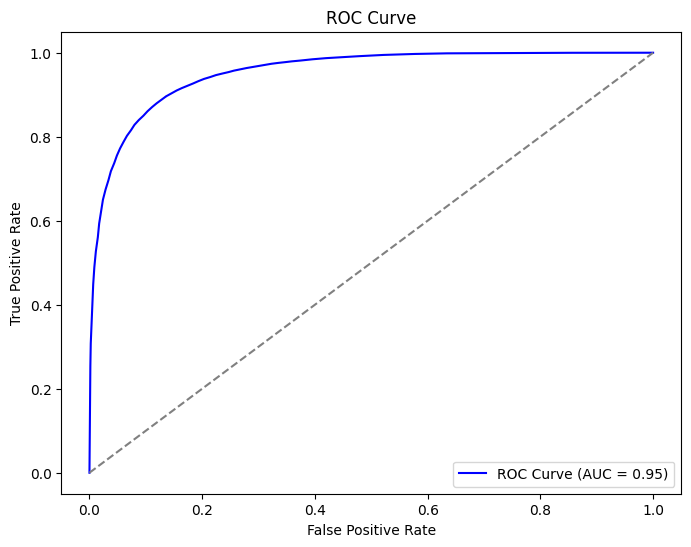

In [23]:
# Train 
random_forest = train_model(X_train_tfidf_balanced, y_train_balanced, model_type='random_forest')

# Evaluate 
print("\nRandom Forest Results:")
evaluate_model(random_forest, X_test_tfidf, y_test)

# Plot ROC Curve 
plot_roc_curve(random_forest, X_test_tfidf, y_test)

- **Accuracy:** **93%**, indicating a highly reliable classification model. 
- **ROC Curve & AUC:**  
  - **AUC = 0.95**, the highest among models so far, suggesting that Random Forest provides **the best separation between positive and negative sentiment**.  

**Insights:**  
✔ **Best model for positive review detection** with high recall and precision.  
✔ **Struggles with negative reviews**, misclassifying **32% of actual negative reviews** as positive.   

**Gradient Boosting**


Gradient Boosting Results:
Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.71      0.54     15682
           1       0.94      0.83      0.88     81046

    accuracy                           0.81     96728
   macro avg       0.69      0.77      0.71     96728
weighted avg       0.86      0.81      0.82     96728

Confusion Matrix:
[[11073  4609]
 [13914 67132]]


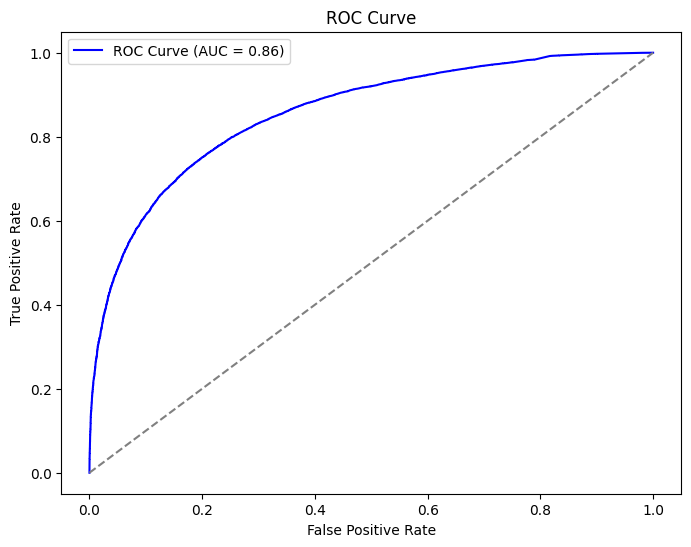

In [25]:
# Train 
gradient_boosting = train_model(X_train_tfidf_balanced, y_train_balanced, model_type='gradient_boosting')

# Evaluate 
print("\nGradient Boosting Results:")
evaluate_model(gradient_boosting, X_test_tfidf, y_test)

# Plot ROC Curve 
plot_roc_curve(gradient_boosting, X_test_tfidf, y_test)

- **Accuracy:** **81%**, which is lower compared to other models like **Random Forest (93%)** and **Logistic Regression (90%)**.
- **ROC Curve & AUC:**  
  - **AUC = 0.86**, the lowest among models, indicating weaker classification performance.  

**Insights:**  
✔ **Strong performance for positive sentiment detection**, but **struggles significantly with negative sentiment**.  
✔ **High false positive rate**, meaning many negative reviews are incorrectly classified as positive.    

In [14]:
# Extract feature importance or coefficients
def get_feature_importance(model, vectorizer, top_n=10):
    """
    Extracts top_n most important features for a given model.
    """
    if hasattr(model, 'coef_'):  # Logistic Regression
        coef = model.coef_[0]
    elif hasattr(model, 'feature_importances_'):  # Random Forest, Gradient Boosting
        coef = model.feature_importances_
    else:
        raise ValueError("The model does not support feature importance extraction.")
    
    feature_names = vectorizer.get_feature_names_out()
    importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': coef
    }).sort_values(by='Importance', ascending=False)
    
    return importance.head(top_n), importance.tail(top_n)

# The most important words for Logistic Regression
positive_words, negative_words = get_feature_importance(logistic_model, vectorizer, top_n=10)

# Display the results
print("Top 10 Positive Words:")
print(positive_words)

print("\nTop 10 Negative Words:")
print(negative_words)

Top 10 Positive Words:
               Feature  Importance
4605              love   21.777371
232            amazing   15.773095
5949           perfect   12.230167
3195             great   12.212215
8081            smooth   10.747073
8160              soft   10.604255
7596         skeptical   10.072756
3506  highly recommend    9.597710
5630            obsess    9.586328
3048              good    9.281765

Top 10 Negative Words:
            Feature  Importance
7267     save money   -6.847136
5004            meh   -7.425757
3262   great review   -7.650682
1867  disappointing   -8.801631
9222  unfortunately   -8.934924
7207          sadly   -9.335139
7037         return  -10.523204
1865   disappointed  -11.076290
9581      want like  -11.169340
9584      want love  -17.334269


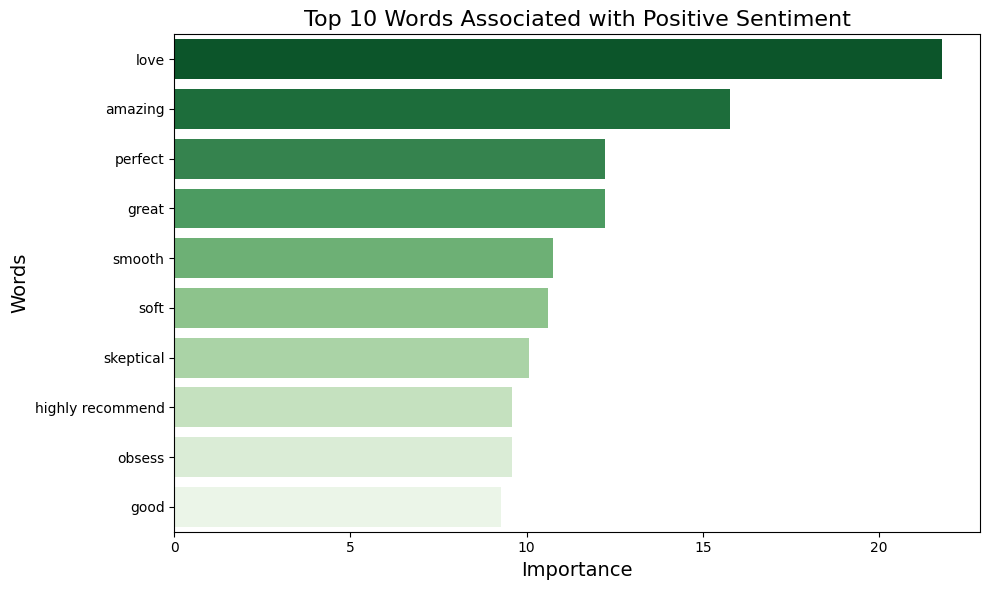

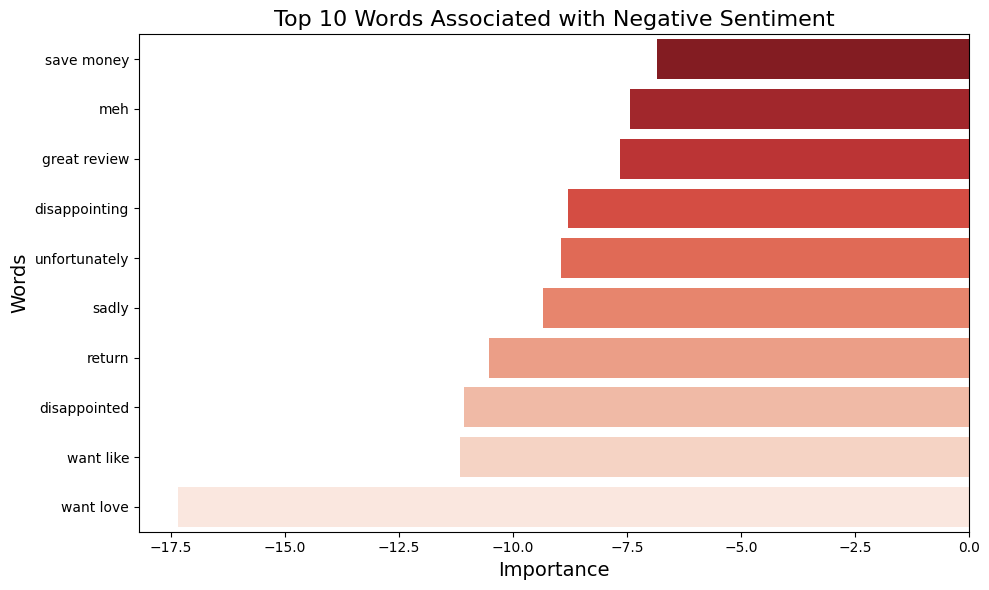

In [15]:
# Fix for Seaborn's FutureWarning
def plot_top_words(importance, title, color):
    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance, x='Importance', y='Feature', hue='Feature', dodge=False, palette=color, legend=False) 
    plt.title(title, fontsize=16)
    plt.xlabel('Importance', fontsize=14)
    plt.ylabel('Words', fontsize=14)
    plt.tight_layout()
    plt.show()

# Call the function again with fixed implementation
plot_top_words(positive_words, "Top 10 Words Associated with Positive Sentiment", "Greens_r")
plot_top_words(negative_words, "Top 10 Words Associated with Negative Sentiment", "Reds_r")

**Word Importance in Sentiment Analysis**

The analysis of word importance in sentiment classification revealed distinct differences in the vocabulary associated with positive and negative reviews. 

- **Top positive words** include *love, amazing, perfect, great, smooth, soft, highly recommend*, and *obsess*, indicating that users emphasize positive emotional experiences, product effectiveness, and recommendation tendencies.
- **Top negative words** such as *save money, meh, great review (ironically in a negative context), disappointing, unfortunately, sadly, return*, and *disappointed* suggest that negative reviews often highlight dissatisfaction, regret, and return-related concerns.

Interestingly, the strongest negative word pair *want love* suggests that customers had high expectations but were ultimately disappointed. This highlights the importance of customer expectations in shaping sentiment.
